In [1]:
import pandas as pd
import numpy as np

import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [10]:
df = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/ChatGPT_data_1.csv")
df

,q_id,gemini,qwen,mistral_ai
0,1,55,70,80
1,2,40,65,30
2,3,40,75,35
3,4,45,80,75
4,5,45,85,30
...,...,...,...,...
65,66,90,85,70
66,67,98,95,85
67,68,98,95,75
68,69,99,98,90


In [11]:
data = [df["gemini"].values, df["qwen"].values, df["mistral_ai"].values]

In [23]:

def fd_bins(x):
    x = np.asarray(x); n = len(x)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    bin_width = 2 * iqr / (n ** (1/3))
    return max(1, int(np.ceil((x.max() - x.min()) / bin_width))) if bin_width > 0 else int(np.sqrt(n))

bins = fd_bins(np.concatenate(data))

<Figure size 800x500 with 0 Axes>

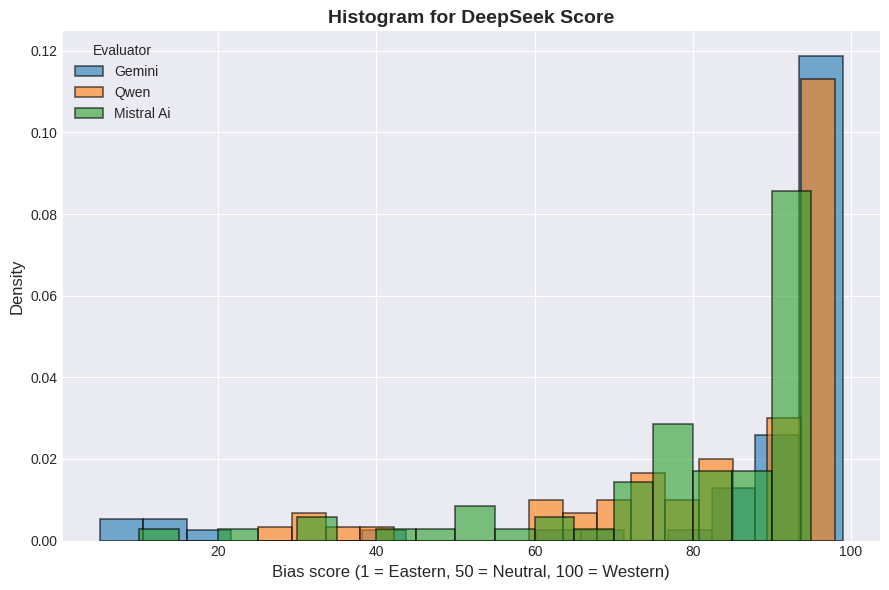

In [25]:
plt.figure(figsize=(8,5))
labels = ["Gemini","Qwen","Mistral Ai"]

plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(9,6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for x, lbl, c in zip(data, labels, colors):
    ax.hist(x, bins=bins, density=True, alpha=0.6, label=lbl,
            color=c, edgecolor="black", linewidth=1.2)

ax.set_title("Histogram for DeepSeek Score", fontsize=14, fontweight="bold")
ax.set_xlabel("Bias score (1 = Eastern, 50 = Neutral, 100 = Western)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(title="Evaluator")
plt.tight_layout()
plt.show()

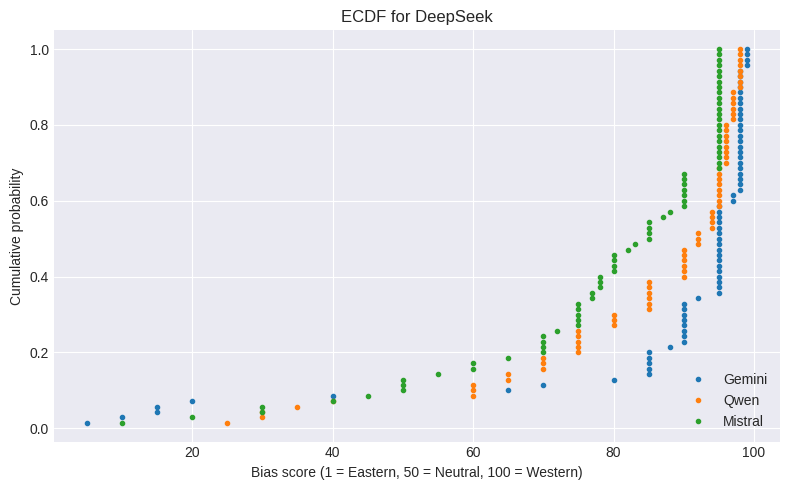

In [26]:
series = {"Gemini": df["gemini"].values, "Qwen": df["qwen"].values, "Mistral": df["mistral_ai"].values}

def ecdf(x):
    x = np.sort(x); y = np.arange(1, len(x)+1) / len(x); return x, y

plt.figure(figsize=(8,5))
for name, x in series.items():
    xs, ys = ecdf(x); plt.plot(xs, ys, marker=".", linestyle="none", label=name)
plt.title("ECDF for DeepSeek")
plt.xlabel("Bias score (1 = Eastern, 50 = Neutral, 100 = Western)")
plt.ylabel("Cumulative probability"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

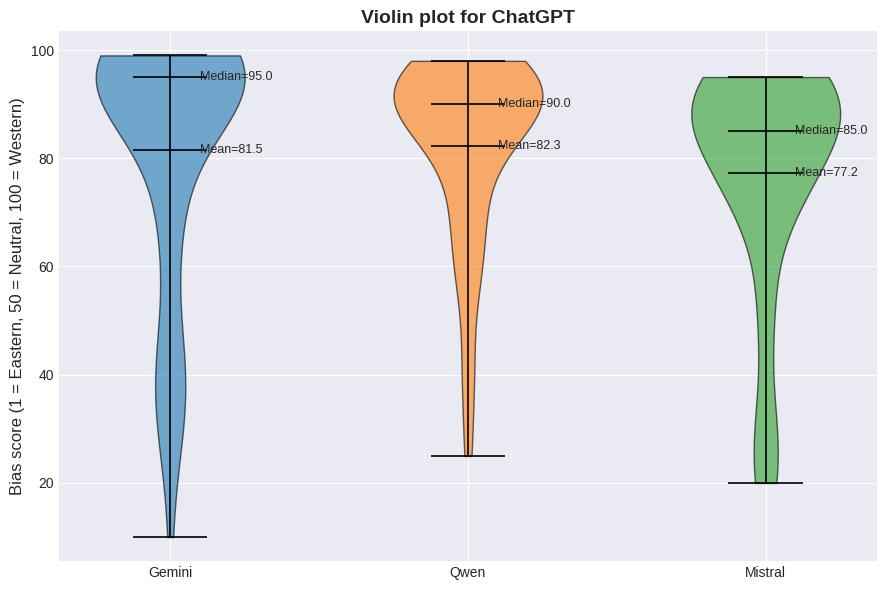

In [12]:
labels = ["Gemini", "Qwen", "Mistral"]

# violin plot
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(9, 6))

parts = ax.violinplot(data, showmeans=True, showmedians=True)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for pc, c in zip(parts['bodies'], colors):
    pc.set_facecolor(c)
    pc.set_edgecolor("black")
    pc.set_alpha(0.6)

for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = parts[partname]
    vp.set_edgecolor("black")
    vp.set_linewidth(1.2)

for i, col in enumerate(data, start=1):
    mean = col.mean()
    median = pd.Series(col).median()
    ax.text(i + 0.1, mean, f"Mean={mean:.1f}", va="center", ha="left", fontsize=9)
    ax.text(i + 0.1, median, f"Median={median:.1f}", va="center", ha="left", fontsize=9)

ax.set_title("Violin plot for ChatGPT", fontsize=14, fontweight="bold")
ax.set_xticks([1,2,3])
ax.set_xticklabels(labels)
ax.set_ylabel("Bias score (1 = Eastern, 50 = Neutral, 100 = Western)", fontsize=12)

plt.tight_layout()
plt.show()



# Pairwise scatter plots

**ChatGPT**

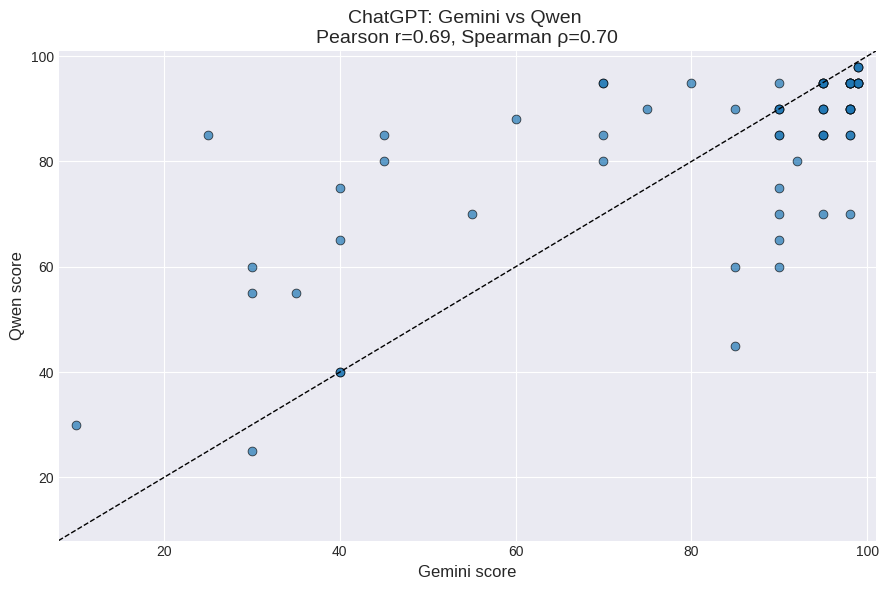

In [36]:
# Pairwise Scatter: Gemini vs Qwen (ChatGPT)


import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

df = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/ChatGPT_data_1.csv")
d = df[["gemini", "qwen"]].dropna()

pr, _ = pearsonr(d["gemini"], d["qwen"])
sr, _ = spearmanr(d["gemini"], d["qwen"])

plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(d["gemini"], d["qwen"], s=40, alpha=0.7, color="#1f77b4",
           edgecolors="black", linewidths=0.6)

lims = [min(d.min())-2, max(d.max())+2]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_title(f"ChatGPT: Gemini vs Qwen \nPearson r={pr:.2f}, Spearman ρ={sr:.2f}",
             fontsize=14)
ax.set_xlabel("Gemini score", fontsize=12)
ax.set_ylabel("Qwen score", fontsize=12)
plt.tight_layout(); plt.show()


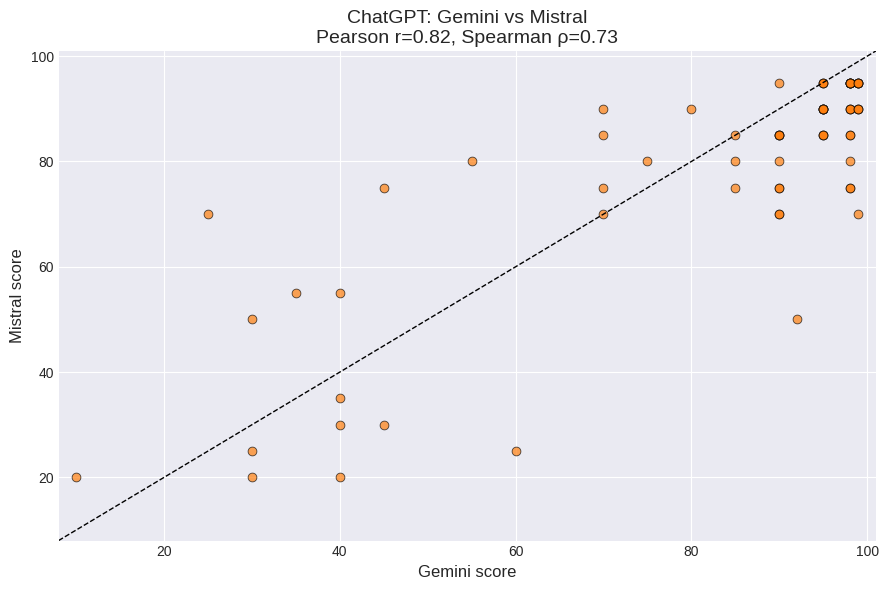

In [37]:
# Pairwise Scatter: Gemini vs Mistral (ChatGPT)


d = df[["gemini", "mistral_ai"]].dropna()

pr, _ = pearsonr(d["gemini"], d["mistral_ai"])
sr, _ = spearmanr(d["gemini"], d["mistral_ai"])

plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(d["gemini"], d["mistral_ai"], s=40, alpha=0.7, color="#ff7f0e",
           edgecolors="black", linewidths=0.6)

lims = [min(d.min())-2, max(d.max())+2]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_title(f"ChatGPT: Gemini vs Mistral\nPearson r={pr:.2f}, Spearman ρ={sr:.2f}",
             fontsize=14)
ax.set_xlabel("Gemini score", fontsize=12)
ax.set_ylabel("Mistral score", fontsize=12)
plt.tight_layout(); plt.show()


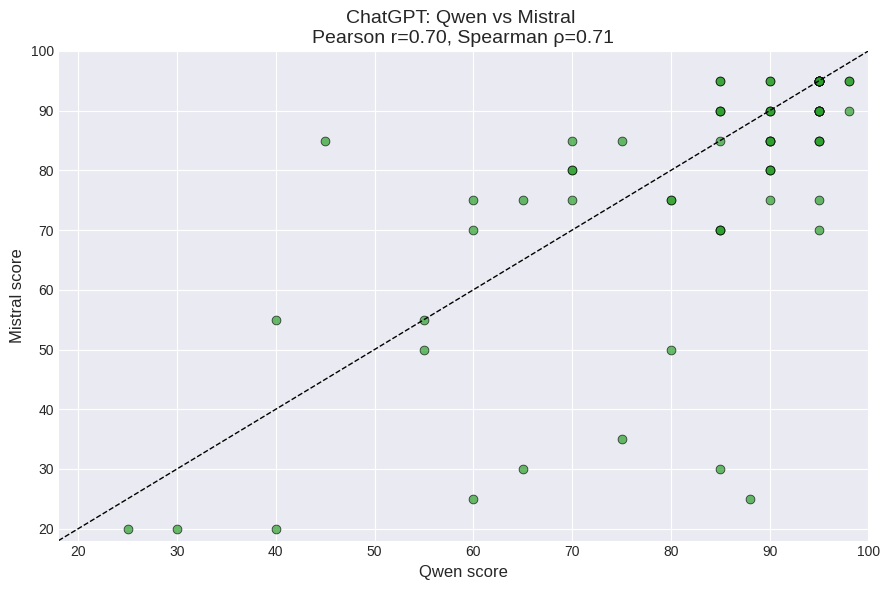

In [38]:
# Pairwise Scatter: Qwen vs Mistral (ChatGPT)


d = df[["qwen", "mistral_ai"]].dropna()

pr, _ = pearsonr(d["qwen"], d["mistral_ai"])
sr, _ = spearmanr(d["qwen"], d["mistral_ai"])

plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(d["qwen"], d["mistral_ai"], s=40, alpha=0.7, color="#2ca02c",
           edgecolors="black", linewidths=0.6)

lims = [min(d.min())-2, max(d.max())+2]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_title(f"ChatGPT: Qwen vs Mistral \nPearson r={pr:.2f}, Spearman ρ={sr:.2f}",
             fontsize=14)
ax.set_xlabel("Qwen score", fontsize=12)
ax.set_ylabel("Mistral score", fontsize=12)
plt.tight_layout(); plt.show()


**DeepSeek**

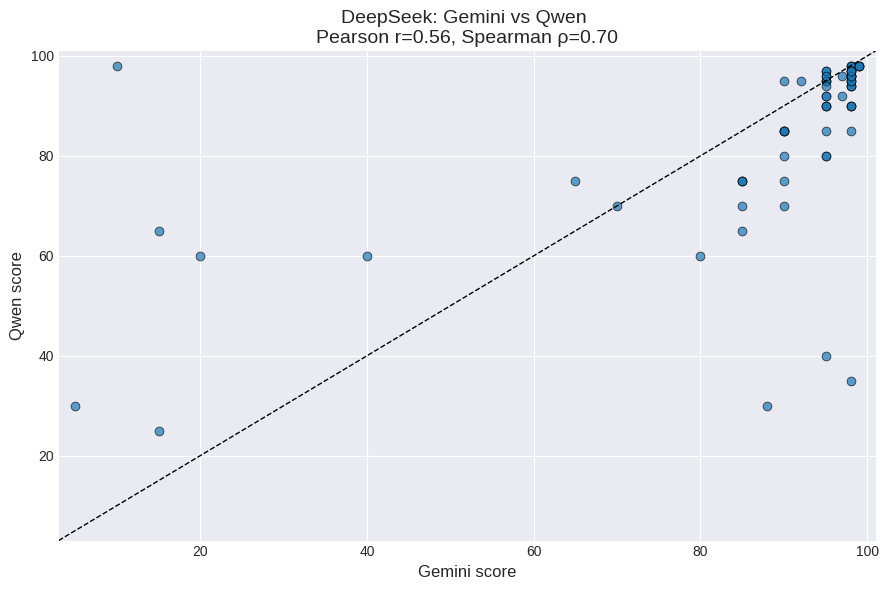

In [40]:
# Pairwise Scatter: Gemini vs Qwen (DeepSeek)


import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

df = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/DeepSeek_data_1.csv")
d = df[["gemini", "qwen"]].dropna()

pr, _ = pearsonr(d["gemini"], d["qwen"])
sr, _ = spearmanr(d["gemini"], d["qwen"])

plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(d["gemini"], d["qwen"], s=40, alpha=0.7, color="#1f77b4",
           edgecolors="black", linewidths=0.6)

lims = [min(d.min())-2, max(d.max())+2]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_title(f"DeepSeek: Gemini vs Qwen \nPearson r={pr:.2f}, Spearman ρ={sr:.2f}",
             fontsize=14)
ax.set_xlabel("Gemini score", fontsize=12)
ax.set_ylabel("Qwen score", fontsize=12)
plt.tight_layout(); plt.show()


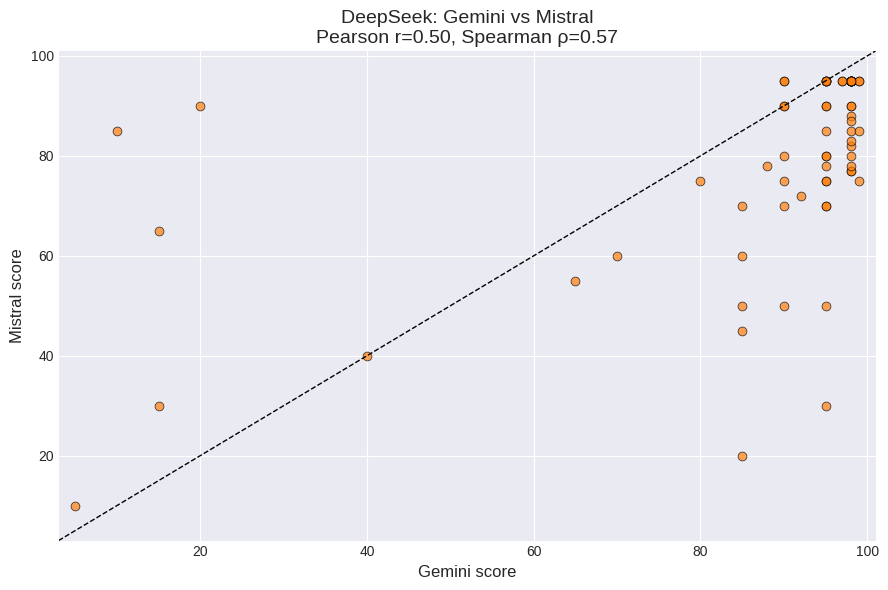

In [41]:
# Pairwise Scatter: Gemini vs Mistral (DeepSeek)


d = df[["gemini", "mistral_ai"]].dropna()

pr, _ = pearsonr(d["gemini"], d["mistral_ai"])
sr, _ = spearmanr(d["gemini"], d["mistral_ai"])

plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(d["gemini"], d["mistral_ai"], s=40, alpha=0.7, color="#ff7f0e",
           edgecolors="black", linewidths=0.6)

lims = [min(d.min())-2, max(d.max())+2]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_title(f"DeepSeek: Gemini vs Mistral\nPearson r={pr:.2f}, Spearman ρ={sr:.2f}",
             fontsize=14)
ax.set_xlabel("Gemini score", fontsize=12)
ax.set_ylabel("Mistral score", fontsize=12)
plt.tight_layout(); plt.show()


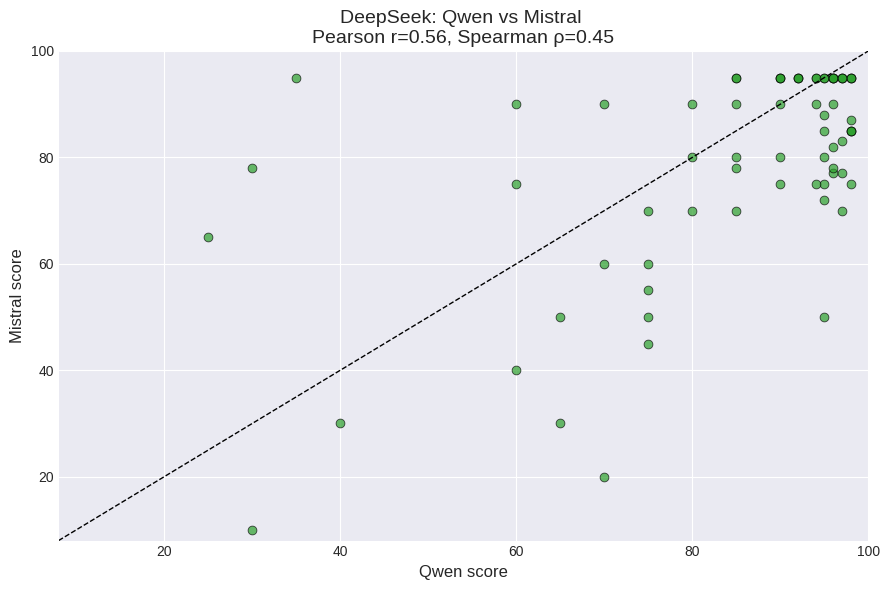

In [42]:
# Pairwise Scatter: Qwen vs Mistral (DeepSeek)


d = df[["qwen", "mistral_ai"]].dropna()

pr, _ = pearsonr(d["qwen"], d["mistral_ai"])
sr, _ = spearmanr(d["qwen"], d["mistral_ai"])

plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(d["qwen"], d["mistral_ai"], s=40, alpha=0.7, color="#2ca02c",
           edgecolors="black", linewidths=0.6)

lims = [min(d.min())-2, max(d.max())+2]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)

ax.set_title(f"DeepSeek: Qwen vs Mistral \nPearson r={pr:.2f}, Spearman ρ={sr:.2f}",
             fontsize=14)
ax.set_xlabel("Qwen score", fontsize=12)
ax.set_ylabel("Mistral score", fontsize=12)
plt.tight_layout(); plt.show()


**Heatmap / Correlation matrix**

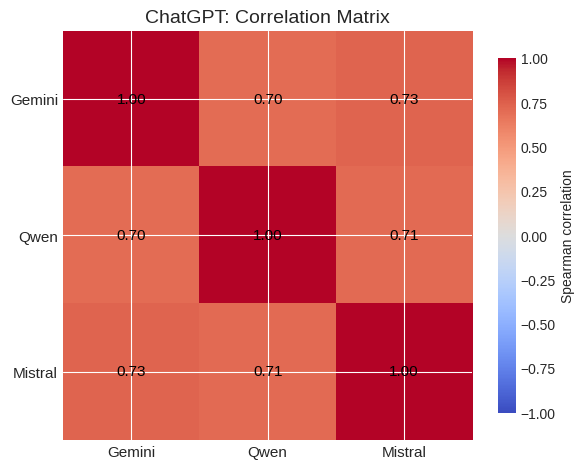

In [50]:
# Heatmap / Correlation Matrix (ChatGPT)

df = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/ChatGPT_data_1.csv")
cols = ["gemini", "qwen", "mistral_ai"]

corr = df[cols].corr(method="spearman").values

plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(["Gemini", "Qwen", "Mistral"], fontsize=11)
ax.set_yticklabels(["Gemini", "Qwen", "Mistral"], fontsize=11)
ax.set_title("ChatGPT: Correlation Matrix", fontsize=14)

# Annotate values
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", color="black", fontsize=11)

fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman correlation")
plt.tight_layout()
plt.show()


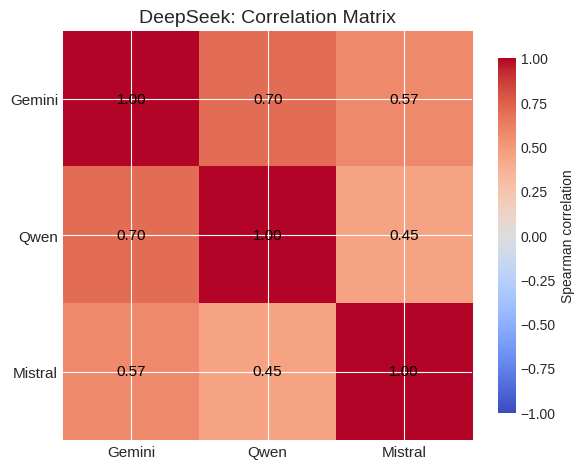

In [51]:
# Heatmap / Correlation Matrix (DeepSeek)

df = pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/DeepSeek_data_1.csv")
cols = ["gemini", "qwen", "mistral_ai"]

corr = df[cols].corr(method="spearman").values

plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(["Gemini", "Qwen", "Mistral"], fontsize=11)
ax.set_yticklabels(["Gemini", "Qwen", "Mistral"], fontsize=11)
ax.set_title("DeepSeek: Correlation Matrix", fontsize=14)

# Annotate values
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", color="black", fontsize=11)

fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman correlation")
plt.tight_layout()
plt.show()
